## Exercise 3
### Exercise 03.1

Nel primo punto viene eseguito un sampling diretto: si genera direttamente il valore finale dello spot price $S(T)$ di un *Geometric Brownian Motion* e, a partire da esso, si calcolano il prezzo della European call option e della European put option, ottenendo i seguenti grafici:

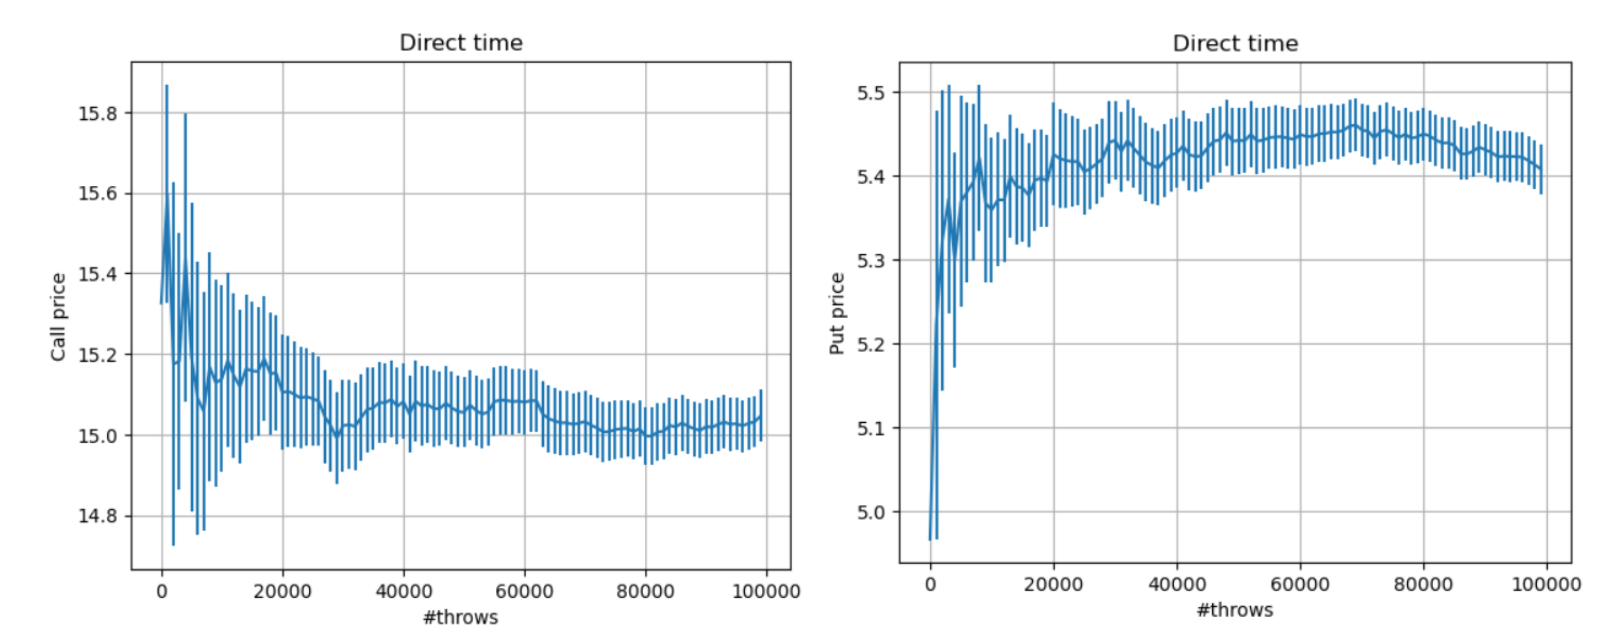

Secondo la soluzione analitica di Black-Scholes, i valori dovrebbero convergere a $14.975790778311286$ per la call e a $5.4595325819072364$ per la put. Come si può osservare dai grafici, il metodo Monte Carlo riproduce questi valori in modo approssimativamente corretto.

Nel secondo punto, invece, non viene utilizzata la formula chiusa per generare direttamente $S(T)$, ma viene simulata l'intera traiettoria dell'attività finanziaria da $t=0$ fino a $t=T$, suddividendo l'intervallo temporale in 100 passi. Il risultato è riassunto nei seguenti grafici:

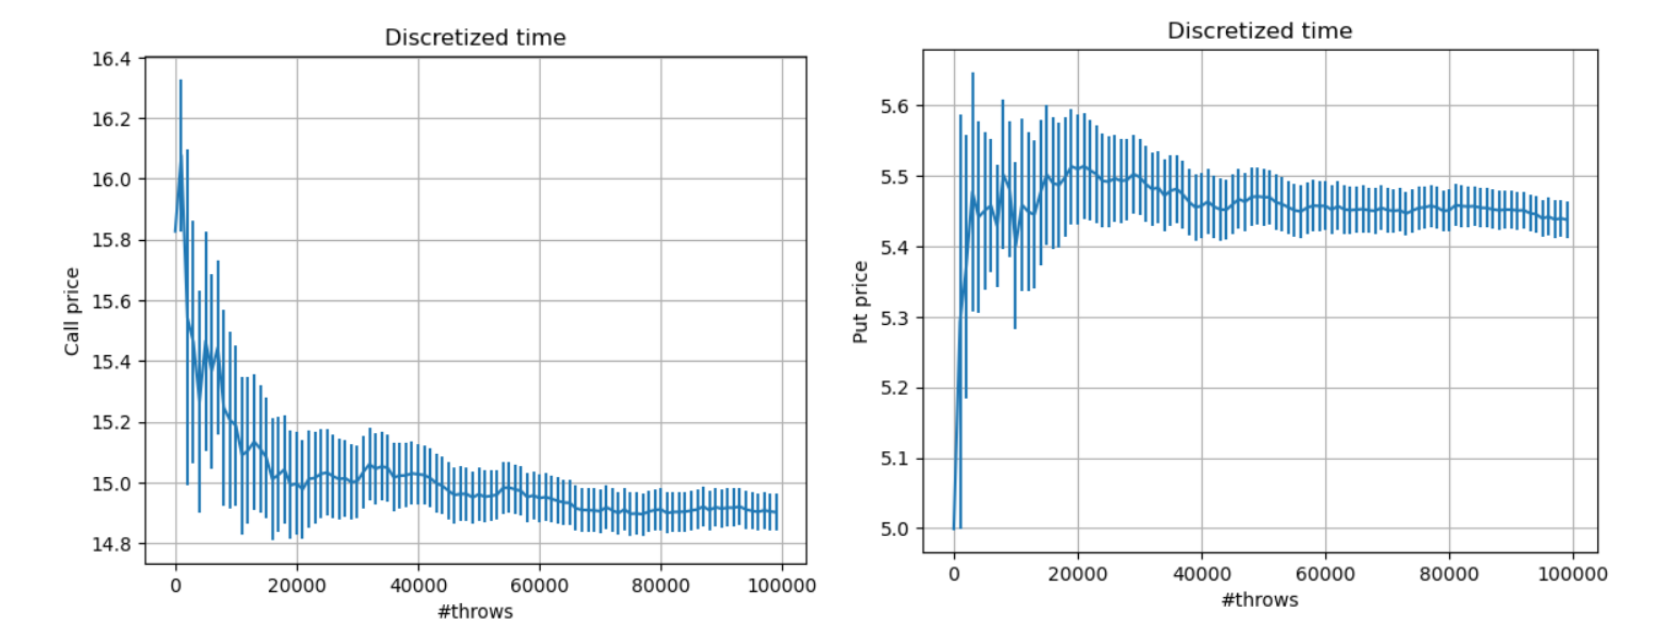

Come nel primo punto, sia il prezzo della call sia quello della put convergono ai valori attesi forniti dalla soluzione di *Black-Scholes*.

Tuttavia, il metodo discretizzato presenta una maggiore incertezza statistica a causa dell'approssimazione temporale introdotta dalla suddivisione in $100$ passi, cosa che non avviene nel metodo basato direttamente sulla soluzione esatta del *Geometric Brownian Motion*.

In [ ]:
# Direct sampling
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt

def error(ave,ave2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((ave2[n] - ave[n]**2)/n)

M=100000              # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block
np.random.seed(1)     # Fixing random seed for reproducibility

x = np.arange(N)      # [0,1,2,...,N-1]

# Arrays for block and progressive averages and errors
call = np.zeros(N)
cal2 = np.zeros(N)
put = np.zeros(N)
pu2 = np.zeros(N)
call_prog = np.zeros(N)
cal2_prog = np.zeros(N)
put_prog = np.zeros(N)
pu2_prog = np.zeros(N)
err_call = np.zeros(N)
err_put = np.zeros(N)

# Black-Scholes parameters
K = 100               # Fixed price
T = 1                 # Delivery time
sigma = 0.25          # Volatility
r = 0.1               # Risk-free interest rate --> mu
S0 = 100              # Asset price at t=0
disc = math.exp(-r*T) # Discount, the interest from the bank

Z = np.random.normal(0, 1, M) # U[0,1) uniform distribution
W = math.sqrt(T)*Z            # W(t) distribution, [0,T)

for i in range(N):
    c = 0
    p = 0
    for j in range(L):
        k = j+i*L
        ST = S0*math.exp((r-0.5*sigma**2)*T+sigma*W[k])  # S(T) from GMB evolution
        c += max(0, ST-K)          # call-option price
        p += max(0, K-ST)          # put-option price
        
    call[i] = disc*c/L             # call_i 
    cal2[i] = call[i]**2           # (call_i)^2
    put[i] = disc*p/L              # put_i 
    pu2[i] = put[i]**2             # (put_i)^2 

for i in range(N):
    for j in range(i+1):
        call_prog[i] += call[j] 
        cal2_prog[i] += cal2[j] 
        put_prog[i] += put[j] 
        pu2_prog[i] += pu2[j]
    call_prog[i]/=(i+1) # Cumulative average in call
    cal2_prog[i]/=(i+1) # Cumulative square average in call
    put_prog[i]/=(i+1) # Cumulative average in put
    pu2_prog[i]/=(i+1) # Cumulative square average in put
    err_call[i] = error(call_prog,cal2_prog,i) # Statistical uncertainty in call
    err_put[i] = error(put_prog,pu2_prog,i) # Statistical uncertainty in put

x *= L # Number of prices = block * (Number of prices in each block)
# Plot: Call-option price
plt.errorbar(x, call_prog, yerr=err_call, label="Call-option price")
plt.xlabel('#throws')
plt.ylabel('Call price')
plt.title('Direct time')
plt.grid(True)
plt.show()
# Plot: Put-option price
plt.errorbar(x, put_prog, yerr=err_put, label="Put-option price ")
plt.xlabel('#throws')
plt.ylabel('Put price')
plt.title('Direct time')
plt.grid(True)
plt.show()

In [ ]:
# Discretized sampling
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt

def error(ave,ave2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((ave2[n] - ave[n]**2)/n)

M=100000              # Total number of throws
N=100                 # Number of blocks
L=int(M/N)            # Number of throws in each block
I=100                 # Number of time intervals
np.random.seed(1)     # Fixing random seed for reproducibility

x = np.arange(N)      # [0,1,2,...,N-1]

# Arrays for block and progressive averages and errors
call = np.zeros(N)
cal2 = np.zeros(N)
put = np.zeros(N)
pu2 = np.zeros(N)
call_prog = np.zeros(N)
cal2_prog = np.zeros(N)
put_prog = np.zeros(N)
pu2_prog = np.zeros(N)
err_call = np.zeros(N)
err_put = np.zeros(N)

# Black-Scholes parameters
K = 100               # Fixed price
T = 1                 # Delivery time
sigma = 0.25          # Volatility
r = 0.1               # Risk-free interest rate --> mu
disc = math.exp(-r*T) # Discount, the interest from the bank

dt = T/I              # Time interval

for i in range(N):
    c = 0
    p = 0
    for j in range(L):
        S = 100                  # Asset price at t=0
        for n in range(I):
            Z = np.random.normal(0, 1) # normal increment for each time step
            S *= math.exp((r-0.5*sigma**2)*dt+sigma*Z*math.sqrt(dt))  # S(T) from GMB evolution
        c += max(0, S-K)     # call-option price
        p += max(0, K-S)     # put-option price
        
    call[i] = disc*c/L           # call_i 
    cal2[i] = call[i]**2         # (call_i)^2
    put[i] = disc*p/L            # put_i 
    pu2[i] = put[i]**2           # (put_i)^2 

for i in range(N):
    for j in range(i+1):
        call_prog[i] += call[j] 
        cal2_prog[i] += cal2[j] 
        put_prog[i] += put[j] 
        pu2_prog[i] += pu2[j]
    call_prog[i]/=(i+1) # Cumulative average in call
    cal2_prog[i]/=(i+1) # Cumulative square average in call
    put_prog[i]/=(i+1) # Cumulative average in put
    pu2_prog[i]/=(i+1) # Cumulative square average in put
    err_call[i] = error(call_prog,cal2_prog,i) # Statistical uncertainty in call
    err_put[i] = error(put_prog,pu2_prog,i) # Statistical uncertainty in put

x *= L # Number of prices = block * (Number of prices in each block)
# Plot: Call-option price
plt.errorbar(x, call_prog, yerr=err_call, label="Call-option price")
plt.xlabel('#throws')
plt.ylabel('Call price')
plt.title('Discretized time')
plt.grid(True)
plt.show()
# Plot: Put-option price
plt.errorbar(x, put_prog, yerr=err_put, label="Put-option price ")
plt.xlabel('#throws')
plt.ylabel('Put price')
plt.title('Discretized time')
plt.grid(True)
plt.show()